In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Company data.csv')
df

,Num,Networth Next Year,Total assets,Net worth,Total income,Change in stock,Total expenses,Profit after tax,PBDITA,PBT,...,Debtors turnover,Finished goods turnover,WIP turnover,Raw material turnover,Shares outstanding,Equity face value,EPS,Adjusted EPS,Total liabilities,PE on BSE
0,1,8890.6,17512.3,7093.2,24965.2,235.8,23657.8,1543.2,2860.2,2417.2,...,3.85,200.55,21.78,7.71,42381675.0,10.0,35.52,7.10,17512.3,27.31
1,2,394.3,941.0,351.5,1527.4,42.7,1454.9,115.2,283.0,188.4,...,5.70,14.21,7.49,11.46,11550000.0,10.0,9.97,9.97,941.0,8.17
2,3,92.2,232.8,100.6,477.3,-5.2,478.7,-6.6,5.8,-6.6,...,5.07,9.24,0.23,NaN,8149090.0,10.0,-0.50,-0.50,232.8,-5.76
3,4,2.7,2.7,2.7,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,NaN,NaN,0.00,52404.0,10.0,0.00,0.00,2.7,NaN
4,5,109.0,478.5,107.6,1580.5,-17.0,1558.0,5.5,31.0,6.3,...,9.46,12.68,7.90,17.03,619635.0,10.0,7.91,7.91,478.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3536,3541,226.4,450.5,172.3,565.0,30.5,581.1,14.4,76.7,41.1,...,20.64,8.66,5.14,19.47,14904213.0,10.0,0.97,0.97,450.5,NaN
3537,3542,89.4,97.6,82.0,75.8,-4.0,66.5,5.3,11.1,6.2,...,14.21,5.13,4.17,4.83,3362800.0,10.0,1.61,1.61,97.6,2.49
3538,3543,246.2,902.9,209.1,1005.1,5.6,966.5,44.2,120.3,70.0,...,3.76,33.03,11.68,4.63,3000000.0,10.0,13.10,13.10,902.9,12.62
3539,3544,146.9,177.0,137.2,371.0,3.9,348.9,26.0,50.5,40.8,...,13.75,49.00,47.03,17.42,4422346.0,10.0,6.06,6.06,177.0,4.07


In [3]:
df.columns

Index(['Num', 'Networth Next Year', 'Total assets', 'Net worth',
       'Total income', 'Change in stock', 'Total expenses', 'Profit after tax',
       'PBDITA', 'PBT', 'Cash profit', 'PBDITA as % of total income',
       'PBT as % of total income', 'PAT as % of total income',
       'Cash profit as % of total income', 'PAT as % of net worth', 'Sales',
       'Income from financial services', 'Other income', 'Total capital',
       'Reserves and funds', 'Deposits (accepted by commercial banks)',
       'Borrowings', 'Current liabilities & provisions',
       'Deferred tax liability', 'Shareholders funds',
       'Cumulative retained profits', 'Capital employed', 'TOL/TNW',
       'Total term liabilities / tangible net worth',
       'Contingent liabilities / Net worth (%)', 'Contingent liabilities',
       'Net fixed assets', 'Investments', 'Current assets',
       'Net working capital', 'Quick ratio (times)', 'Current ratio (times)',
       'Debt to equity ratio (times)', 'Cash to cur

##### As you can see there are mutiple errors in column names lile %, (, ), spaces etc thus u need to correct it

In [4]:
df.columns=df.columns.str.replace(' ','_').str.replace('%','perc').str.replace('(',' ').str.replace(')',' ').str.replace('/','upon')

In [5]:
df.columns

Index(['Num', 'Networth_Next_Year', 'Total_assets', 'Net_worth',
       'Total_income', 'Change_in_stock', 'Total_expenses', 'Profit_after_tax',
       'PBDITA', 'PBT', 'Cash_profit', 'PBDITA_as_perc_of_total_income',
       'PBT_as_perc_of_total_income', 'PAT_as_perc_of_total_income',
       'Cash_profit_as_perc_of_total_income', 'PAT_as_perc_of_net_worth',
       'Sales', 'Income_from_financial_services', 'Other_income',
       'Total_capital', 'Reserves_and_funds',
       'Deposits_ accepted_by_commercial_banks ', 'Borrowings',
       'Current_liabilities_&_provisions', 'Deferred_tax_liability',
       'Shareholders_funds', 'Cumulative_retained_profits', 'Capital_employed',
       'TOLuponTNW', 'Total_term_liabilities_upon_tangible_net_worth',
       'Contingent_liabilities_upon_Net_worth_ perc ',
       'Contingent_liabilities', 'Net_fixed_assets', 'Investments',
       'Current_assets', 'Net_working_capital', 'Quick_ratio_ times ',
       'Current_ratio_ times ', 'Debt_to_equity_r

In [6]:
df.shape

(3541, 52)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3541 entries, 0 to 3540
Data columns (total 52 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Num                                             3541 non-null   int64  
 1   Networth_Next_Year                              3541 non-null   float64
 2   Total_assets                                    3541 non-null   float64
 3   Net_worth                                       3541 non-null   float64
 4   Total_income                                    3343 non-null   float64
 5   Change_in_stock                                 3083 non-null   float64
 6   Total_expenses                                  3402 non-null   float64
 7   Profit_after_tax                                3410 non-null   float64
 8   PBDITA                                          3410 non-null   float64
 9   PBT                                      

##### Mutiple missing data is there

In [8]:
df.describe().round(2)

,Num,Networth_Next_Year,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,...,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities,PE_on_BSE
count,3541.00,3541.00,3541.00,3541.00,3343.00,3083.00,3402.00,3410.00,3410.00,3410.00,...,3213.00,2801.00,2901.00,3180.00,2.849000e+03,2849.00,3541.00,3541.00,3541.00,1347.00
mean,1772.45,1616.26,3443.38,1295.86,4582.82,41.49,4262.93,277.36,578.06,383.81,...,17.04,87.08,27.93,19.09,2.206739e+07,-1333.70,-220.32,-221.51,3443.38,63.91
std,1023.73,17459.64,30970.89,13387.89,55681.24,440.57,53028.69,3064.41,5653.77,4117.07,...,83.94,598.55,151.04,376.34,1.655193e+08,37500.73,14261.95,14261.92,30970.89,1433.81
min,1.00,-74265.60,0.10,0.00,0.00,-3029.40,-0.10,-3908.30,-440.70,-3894.80,...,0.00,-0.09,-0.18,-2.00,-2.147484e+09,-999998.90,-843181.82,-843181.82,0.10,-1116.64
25%,886.00,31.70,91.30,31.30,106.45,-1.80,95.82,0.50,6.90,0.70,...,3.76,8.20,5.10,2.99,1.316250e+06,10.00,0.00,0.00,91.30,3.28
50%,1773.00,116.30,309.70,102.30,444.90,1.60,407.70,8.80,35.40,12.40,...,6.32,17.27,9.76,6.40,4.672063e+06,10.00,1.43,1.18,309.70,9.10
75%,2658.00,456.10,1098.70,377.30,1440.90,18.05,1359.78,52.28,150.25,71.97,...,11.68,40.35,20.24,11.84,1.065197e+07,10.00,9.62,7.48,1098.70,17.79
max,3545.00,805773.40,1176509.20,613151.60,2442828.20,14185.50,2366035.30,119439.10,208576.50,145292.60,...,3135.20,17947.60,5651.40,21092.00,4.130401e+09,100000.00,34522.53,34522.53,1176509.20,51002.74


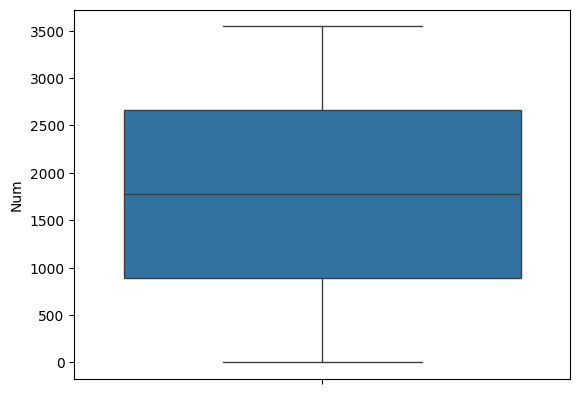

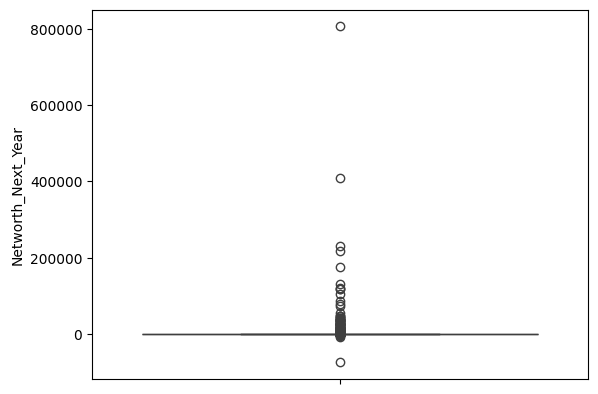

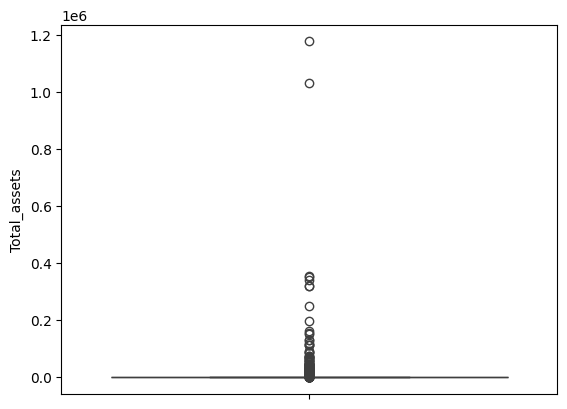

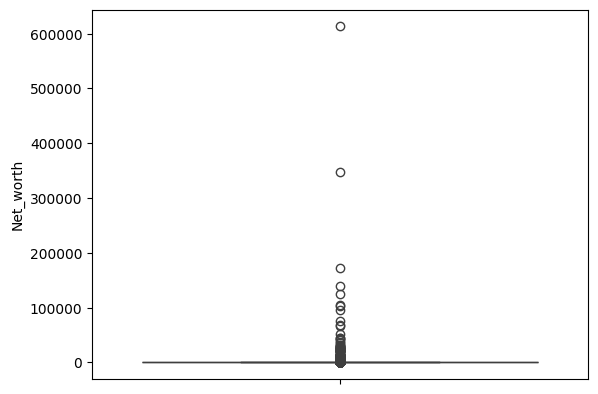

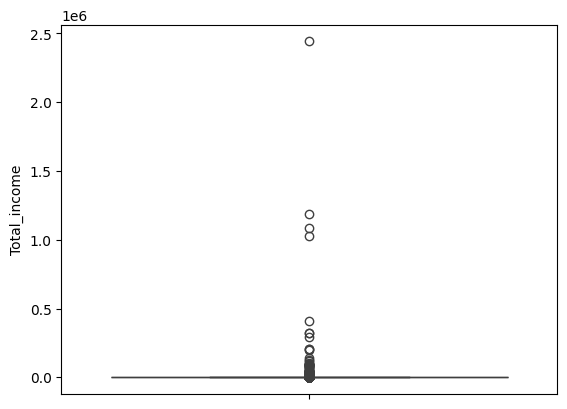

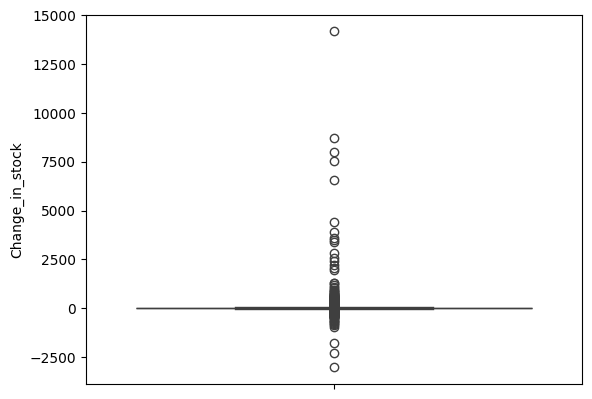

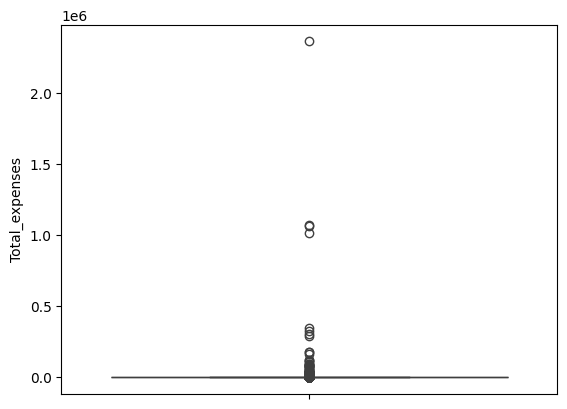

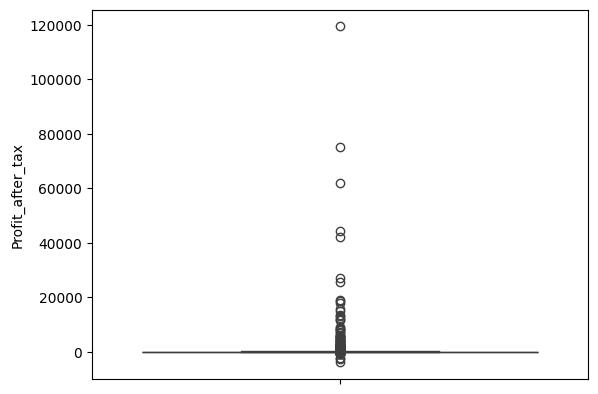

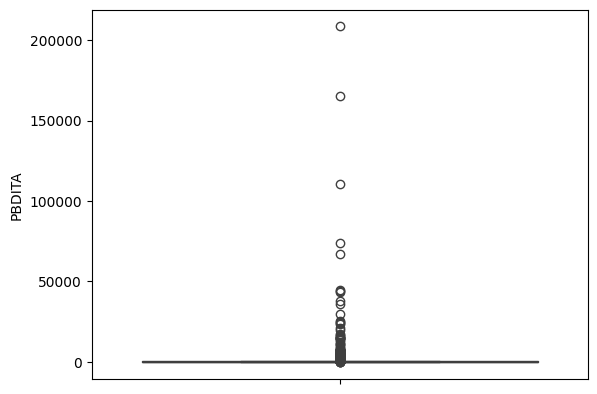

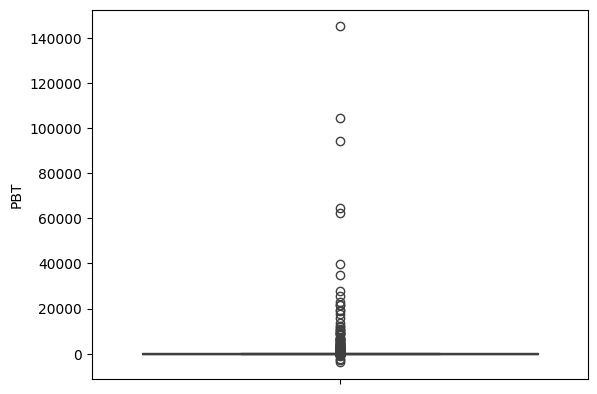

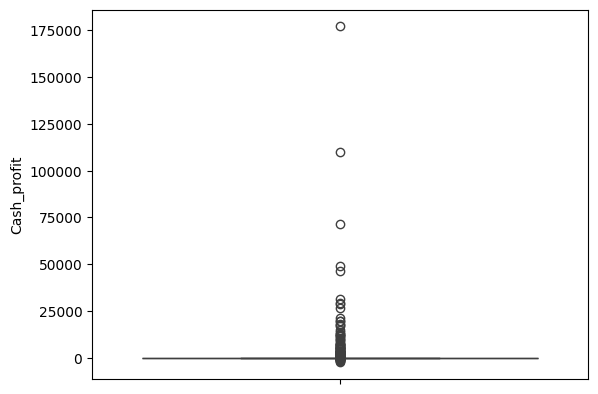

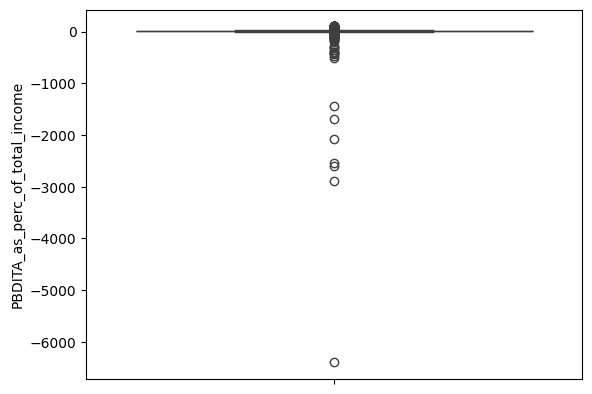

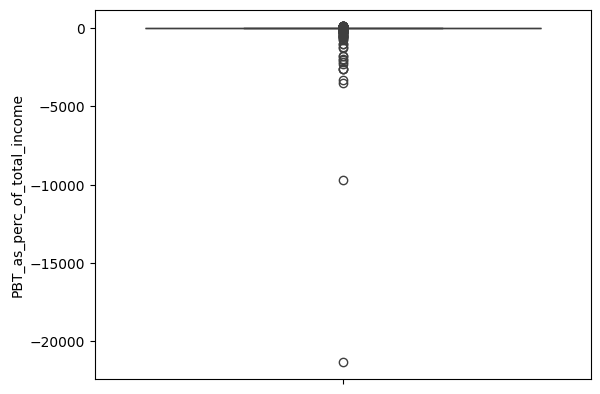

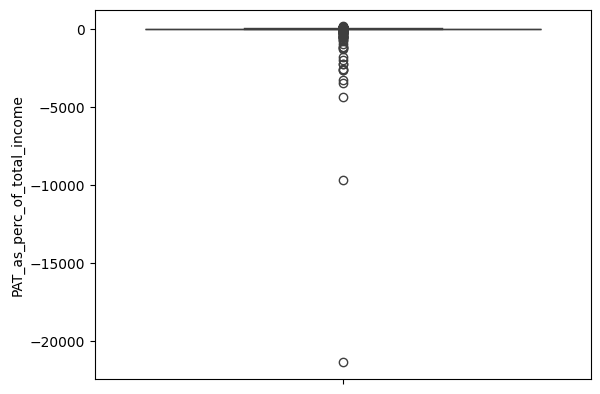

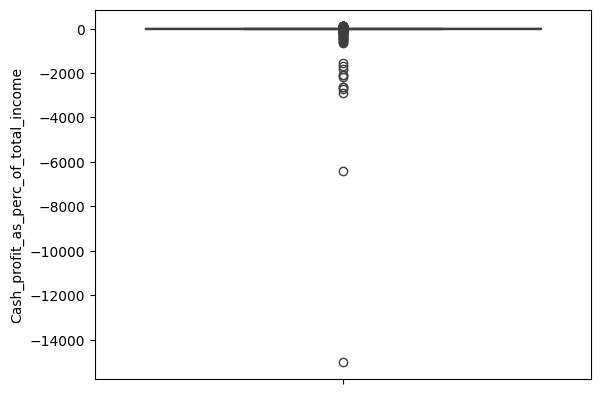

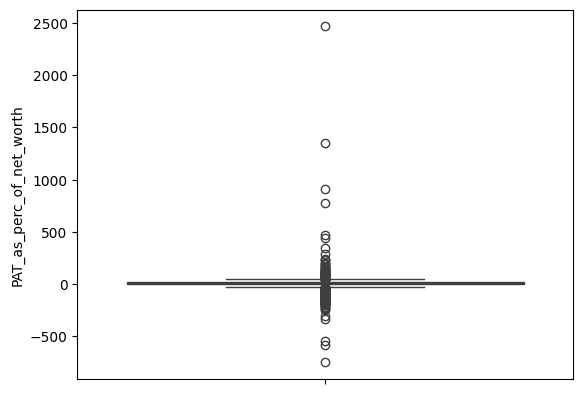

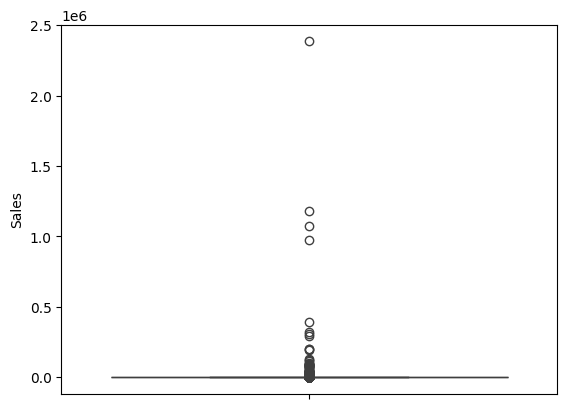

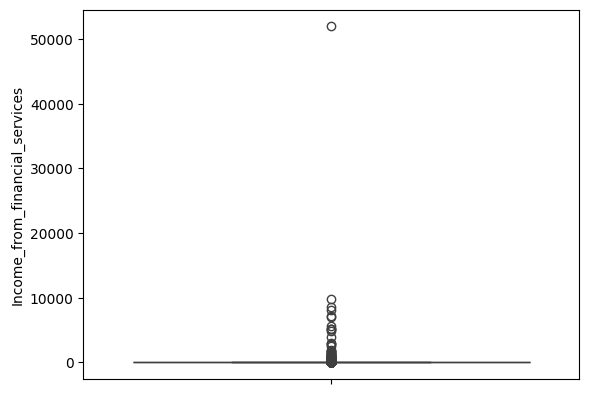

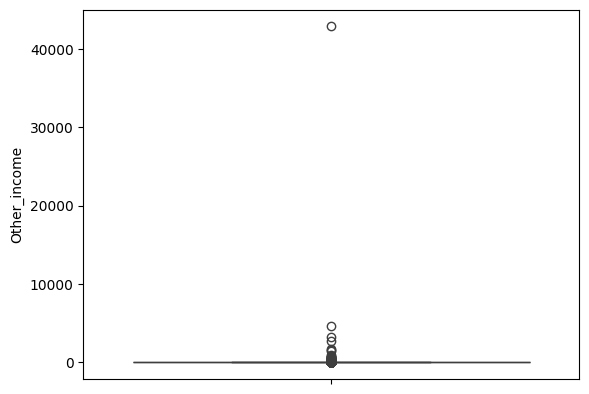

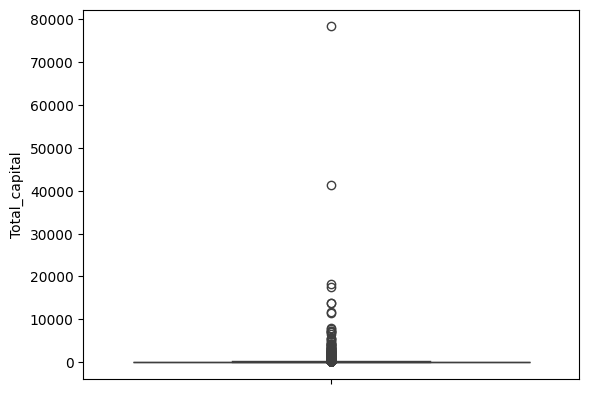

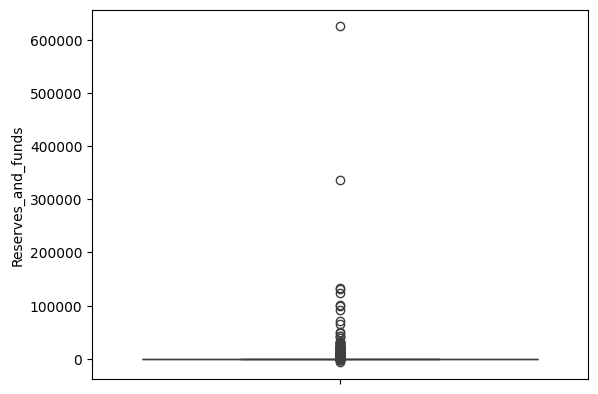

ValueError: List of boxplot statistics and `positions` values must have same the length

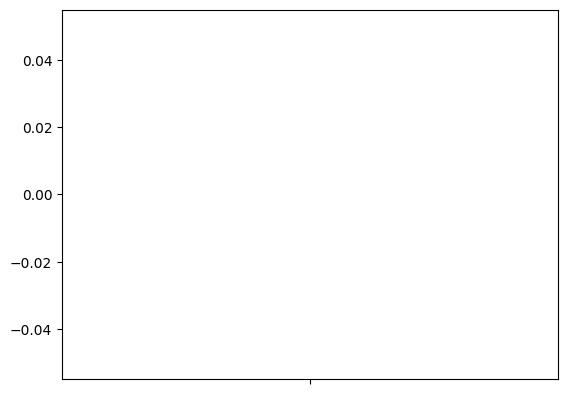

In [9]:
def plotbx(col):
    sns.boxplot(df[col])
    plt.show()
for i in df.columns:
    plotbx(i)

#### Our Y is not in data thus we have to create it usinh np.where by the condition
        where networth per annum is greater than 0 Y is 1 else 0 give in Data definition

In [5]:
df['default']=np.where(df['Networth_Next_Year']>0, 1, 0)

In [6]:
df[['default','Networth_Next_Year']].head(10)

,default,Networth_Next_Year
0,1,8890.6
1,1,394.3
2,1,92.2
3,1,2.7
4,1,109.0
5,1,688.6
6,1,246.0
7,1,13.7
8,1,291.5
9,0,-7.3


### Check for imbalance data

In [13]:
df.default.value_counts()

default
1    3298
0     243
Name: count, dtype: int64

In [14]:
df.default.value_counts(normalize=True)

default
1    0.931375
0    0.068625
Name: proportion, dtype: float64

##### Highly imbalance data

In [15]:
df.duplicated().sum()

np.int64(0)

##### no duplicate data

In [16]:
df.isna().sum().sum()

np.int64(18533)

In [17]:
df.isna().sum()/len(df) *100

Num                                                 0.000000
Networth_Next_Year                                  0.000000
Total_assets                                        0.000000
Net_worth                                           0.000000
Total_income                                        5.591641
Change_in_stock                                    12.934199
Total_expenses                                      3.925445
Profit_after_tax                                    3.699520
PBDITA                                              3.699520
PBT                                                 3.699520
Cash_profit                                         3.699520
PBDITA_as_perc_of_total_income                      1.920361
PBT_as_perc_of_total_income                         1.920361
PAT_as_perc_of_total_income                         1.920361
Cash_profit_as_perc_of_total_income                 1.920361
PAT_as_perc_of_net_worth                            0.000000
Sales                   

### Lets check outlier using IQR

In [13]:
# Q1=df.quantile(0.25)
# Q3=df.quantile(0.75)
# IQR=Q3-Q1
# upper_limit=Q3 + 1.5 * IQR
# lower_limit=Q1 - 1.5 * IQR

In [14]:
# ((df > upper_limit)|(df < lower_limit)).sum()

##### These are the number are outlier

In [15]:
# df[((df > upper_limit)|(df < lower_limit))]=np.nan

##### changing the outlier to nan so it can easily handled
    Now the number of missing value will be changed

In [16]:
# df.isnull().sum().sum()

In [17]:
# df['default'].isna().sum()

##### Look here problem is it is considring DV as well thus we have to split the data then chnage it then concat it agian

In [7]:
IV=df.drop(columns='default',axis=1)
DV=df.default

In [8]:
IV

,Num,Networth_Next_Year,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,...,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities,PE_on_BSE
0,1,8890.6,17512.3,7093.2,24965.2,235.8,23657.8,1543.2,2860.2,2417.2,...,3.85,200.55,21.78,7.71,42381675.0,10.0,35.52,7.10,17512.3,27.31
1,2,394.3,941.0,351.5,1527.4,42.7,1454.9,115.2,283.0,188.4,...,5.70,14.21,7.49,11.46,11550000.0,10.0,9.97,9.97,941.0,8.17
2,3,92.2,232.8,100.6,477.3,-5.2,478.7,-6.6,5.8,-6.6,...,5.07,9.24,0.23,NaN,8149090.0,10.0,-0.50,-0.50,232.8,-5.76
3,4,2.7,2.7,2.7,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,NaN,NaN,0.00,52404.0,10.0,0.00,0.00,2.7,NaN
4,5,109.0,478.5,107.6,1580.5,-17.0,1558.0,5.5,31.0,6.3,...,9.46,12.68,7.90,17.03,619635.0,10.0,7.91,7.91,478.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3536,3541,226.4,450.5,172.3,565.0,30.5,581.1,14.4,76.7,41.1,...,20.64,8.66,5.14,19.47,14904213.0,10.0,0.97,0.97,450.5,NaN
3537,3542,89.4,97.6,82.0,75.8,-4.0,66.5,5.3,11.1,6.2,...,14.21,5.13,4.17,4.83,3362800.0,10.0,1.61,1.61,97.6,2.49
3538,3543,246.2,902.9,209.1,1005.1,5.6,966.5,44.2,120.3,70.0,...,3.76,33.03,11.68,4.63,3000000.0,10.0,13.10,13.10,902.9,12.62
3539,3544,146.9,177.0,137.2,371.0,3.9,348.9,26.0,50.5,40.8,...,13.75,49.00,47.03,17.42,4422346.0,10.0,6.06,6.06,177.0,4.07


In [9]:
# now perform operation on IV
Q1=IV.quantile(0.25)
Q3=IV.quantile(0.75)
IQR=Q3-Q1
upper_limit=Q3 + 1.5 * IQR
lower_limit=Q1 - 1.5 * IQR

In [10]:
((IV > upper_limit)|(IV < lower_limit)).sum()

Num                                                 0
Networth_Next_Year                                506
Total_assets                                      484
Net_worth                                         499
Total_income                                      427
Change_in_stock                                   621
Total_expenses                                    432
Profit_after_tax                                  577
PBDITA                                            483
PBT                                               576
Cash_profit                                       515
PBDITA_as_perc_of_total_income                    287
PBT_as_perc_of_total_income                       453
PAT_as_perc_of_total_income                       502
Cash_profit_as_perc_of_total_income               353
PAT_as_perc_of_net_worth                          344
Sales                                             418
Income_from_financial_services                    432
Other_income                

In [11]:
IV[((IV > upper_limit)|(IV < lower_limit))]=np.nan

In [12]:
IV.isnull().sum().sum()

np.int64(39981)

In [13]:
39981 - 18533

21448

###### outliere this much

### Remove unnecassary columns
    here Networth_Next_Year is remvoed coz it is already used to create default
    remove columns with missing value more than 25% but note the DF null values

In [14]:
IV=IV.drop(columns=['Num','Networth_Next_Year','Income_from_financial_services','Other_income','Deposits_ accepted_by_commercial_banks ','Deferred_tax_liability','Contingent_liabilities','Investments','PE_on_BSE'],axis=1)

In [15]:
IV.shape

(3541, 43)

##### Now combine data

In [16]:
df_1=pd.concat([IV,DV],axis=1)
df_1

,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,Cash_profit,PBDITA_as_perc_of_total_income,...,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities,default
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.46,...,3.85,NaN,21.78,7.71,NaN,10.0,NaN,7.10,NaN,1
1,941.0,351.5,1527.4,42.7,1454.9,115.2,283.0,NaN,158.6,18.53,...,5.70,14.21,7.49,11.46,11550000.0,10.0,9.97,9.97,941.0,1
2,232.8,100.6,477.3,-5.2,478.7,-6.6,5.8,-6.6,0.3,1.22,...,5.07,9.24,0.23,NaN,8149090.0,10.0,-0.50,-0.50,232.8,1
3,2.7,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,...,0.00,NaN,NaN,0.00,52404.0,10.0,0.00,0.00,2.7,1
4,478.5,107.6,1580.5,-17.0,1558.0,5.5,31.0,6.3,11.9,1.96,...,9.46,12.68,7.90,17.03,619635.0,10.0,7.91,7.91,478.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3536,450.5,172.3,565.0,30.5,581.1,14.4,76.7,41.1,48.4,13.58,...,20.64,8.66,5.14,19.47,14904213.0,10.0,0.97,0.97,450.5,1
3537,97.6,82.0,75.8,-4.0,66.5,5.3,11.1,6.2,9.2,14.64,...,14.21,5.13,4.17,4.83,3362800.0,10.0,1.61,1.61,97.6,1
3538,902.9,209.1,1005.1,5.6,966.5,44.2,120.3,70.0,62.6,11.97,...,3.76,33.03,11.68,4.63,3000000.0,10.0,13.10,13.10,902.9,1
3539,177.0,137.2,371.0,3.9,348.9,26.0,50.5,40.8,33.6,13.61,...,13.75,49.00,NaN,17.42,4422346.0,10.0,6.06,6.06,177.0,1


In [17]:
df_1.isna().sum()/len(df) * 100

Total_assets                                      13.668455
Net_worth                                         14.092064
Total_income                                      17.650381
Change_in_stock                                   30.471618
Total_expenses                                    16.125388
Profit_after_tax                                  19.994352
PBDITA                                            17.339735
PBT                                               19.966111
Cash_profit                                       18.243434
PBDITA_as_perc_of_total_income                    10.025417
PBT_as_perc_of_total_income                       14.713358
PAT_as_perc_of_total_income                       16.097148
Cash_profit_as_perc_of_total_income               11.889297
PAT_as_perc_of_net_worth                           9.714770
Sales                                             19.118893
Total_capital                                     12.651793
Reserves_and_funds                      

### remove the rows as well where 25% of data is missing
    44*25/100   (44= Total columns, 25/100=25)-----------------> ROW Wise Removal

In [18]:
# df_1.isna().sum(axis=1) # this is row wise

In [19]:
## now drop those rows where NA sum is 11( 25% of 43)
# df_2=df_1[df_1.isna().sum(axis=1) <= 11] # choose rows having nan value less than 11

In [20]:
# df_2.shape

In [21]:
# df_2.describe()

#### You can see there are differnt values of differnt range there feature scalling is done
## Feature Scaling

In [22]:
X=df_1.drop('default',axis=1)
Y=df_1['default']

In [23]:
X

,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,Cash_profit,PBDITA_as_perc_of_total_income,...,Creditors_turnover,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.46,...,3.62,3.85,NaN,21.78,7.71,NaN,10.0,NaN,7.10,NaN
1,941.0,351.5,1527.4,42.7,1454.9,115.2,283.0,NaN,158.6,18.53,...,9.80,5.70,14.21,7.49,11.46,11550000.0,10.0,9.97,9.97,941.0
2,232.8,100.6,477.3,-5.2,478.7,-6.6,5.8,-6.6,0.3,1.22,...,5.28,5.07,9.24,0.23,NaN,8149090.0,10.0,-0.50,-0.50,232.8
3,2.7,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,...,0.00,0.00,NaN,NaN,0.00,52404.0,10.0,0.00,0.00,2.7
4,478.5,107.6,1580.5,-17.0,1558.0,5.5,31.0,6.3,11.9,1.96,...,13.00,9.46,12.68,7.90,17.03,619635.0,10.0,7.91,7.91,478.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3536,450.5,172.3,565.0,30.5,581.1,14.4,76.7,41.1,48.4,13.58,...,15.65,20.64,8.66,5.14,19.47,14904213.0,10.0,0.97,0.97,450.5
3537,97.6,82.0,75.8,-4.0,66.5,5.3,11.1,6.2,9.2,14.64,...,10.07,14.21,5.13,4.17,4.83,3362800.0,10.0,1.61,1.61,97.6
3538,902.9,209.1,1005.1,5.6,966.5,44.2,120.3,70.0,62.6,11.97,...,3.96,3.76,33.03,11.68,4.63,3000000.0,10.0,13.10,13.10,902.9
3539,177.0,137.2,371.0,3.9,348.9,26.0,50.5,40.8,33.6,13.61,...,NaN,13.75,49.00,NaN,17.42,4422346.0,10.0,6.06,6.06,177.0


In [24]:
Y

0       1
1       1
2       1
3       1
4       1
       ..
3536    1
3537    1
3538    1
3539    1
3540    0
Name: default, Length: 3541, dtype: int64

In [25]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)
x_scaled=pd.DataFrame(x_scaled,columns=X.columns)
x_scaled

,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,Cash_profit,PBDITA_as_perc_of_total_income,...,Creditors_turnover,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.127839,...,-0.616560,-0.597170,NaN,1.143298,0.105724,NaN,0.0,NaN,1.046657,NaN
1,0.857364,1.040021,1.169560,2.929613,1.187136,3.369301,2.796202,NaN,2.463083,1.046692,...,0.639601,-0.232877,-0.366744,-0.417817,0.744868,1.222365,0.0,1.165458,1.675933,0.857364
2,-0.409188,-0.276449,-0.203697,-0.739865,-0.161047,-0.765968,-0.644752,-0.716398,-0.639534,-1.203003,...,-0.279145,-0.356933,-0.625116,-1.210937,NaN,0.574110,0.0,-0.607066,-0.619719,-0.409188
3,-0.820702,-0.790130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.361560,...,-1.352370,-1.355293,NaN,NaN,-1.208357,-0.969217,0.0,-0.522419,-0.510089,-0.820702
4,0.030224,-0.239720,1.239001,-1.643828,1.329523,-0.355157,-0.331938,-0.394099,-0.412179,-1.106829,...,1.290041,0.507524,-0.446283,-0.373026,1.694209,-0.861096,0.0,0.816709,1.224258,0.030224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3536,-0.019852,0.099760,-0.089008,1.995007,-0.019628,-0.052991,0.235348,0.475361,0.303207,0.403365,...,1.828686,2.709036,-0.655268,-0.674543,2.110079,1.861718,0.0,-0.358202,-0.297407,-0.019852
3537,-0.650981,-0.374043,-0.728754,-0.647936,-0.730317,-0.361948,-0.578961,-0.396597,-0.465098,0.541128,...,0.694482,1.442872,-0.838780,-0.780511,-0.385139,-0.338215,0.0,-0.249853,-0.157080,-0.650981
3538,0.789225,0.292849,0.486528,0.087491,0.512630,0.958758,0.776566,1.197412,0.581521,0.194122,...,-0.547451,-0.614892,0.611638,0.039921,-0.419227,-0.407369,0.0,1.695353,2.362217,0.789225
3539,-0.508982,-0.084409,-0.342709,-0.042741,-0.340308,0.340845,-0.089879,0.467866,0.013133,0.407264,...,NaN,1.352291,1.441859,NaN,1.760680,-0.136253,0.0,0.503512,0.818627,-0.508982


In [26]:
x_scaled.describe().round(2)

,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,Cash_profit,PBDITA_as_perc_of_total_income,...,Creditors_turnover,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities
count,3057.00,3042.00,2916.00,2462.00,2970.00,2833.00,2927.00,2834.00,2895.00,3186.00,...,2839.00,2877.00,2475.00,2585.00,2933.00,2456.00,2413.0,3001.00,2959.00,3057.00
mean,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,...,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.0,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,0.0,1.00,1.00,1.00
min,-0.83,-0.80,-0.83,-2.74,-0.82,-3.15,-3.27,-3.09,-3.24,-2.83,...,-1.35,-1.36,-1.11,-1.26,-1.55,-0.98,0.0,-2.93,-2.90,-0.83
25%,-0.70,-0.68,-0.72,-0.44,-0.72,-0.53,-0.66,-0.54,-0.61,-0.69,...,-0.66,-0.67,-0.72,-0.73,-0.74,-0.79,0.0,-0.52,-0.51,-0.70
50%,-0.41,-0.41,-0.42,-0.26,-0.42,-0.38,-0.41,-0.38,-0.40,-0.15,...,-0.24,-0.23,-0.35,-0.31,-0.21,-0.25,0.0,-0.43,-0.40,-0.41
75%,0.29,0.25,0.36,0.36,0.36,0.22,0.27,0.20,0.25,0.61,...,0.48,0.50,0.39,0.46,0.51,0.36,0.0,0.32,0.31,0.29
max,3.84,3.85,3.66,3.31,3.64,3.85,3.81,3.90,3.83,2.98,...,3.34,3.28,3.48,3.45,3.06,3.71,0.0,3.55,3.57,3.84


In [27]:
df_2=pd.concat([x_scaled,Y],axis=1)
df_2

,Total_assets,Net_worth,Total_income,Change_in_stock,Total_expenses,Profit_after_tax,PBDITA,PBT,Cash_profit,PBDITA_as_perc_of_total_income,...,Debtors_turnover,Finished_goods_turnover,WIP_turnover,Raw_material_turnover,Shares_outstanding,Equity_face_value,EPS,Adjusted_EPS,Total_liabilities,default
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.127839,...,-0.597170,NaN,1.143298,0.105724,NaN,0.0,NaN,1.046657,NaN,1
1,0.857364,1.040021,1.169560,2.929613,1.187136,3.369301,2.796202,NaN,2.463083,1.046692,...,-0.232877,-0.366744,-0.417817,0.744868,1.222365,0.0,1.165458,1.675933,0.857364,1
2,-0.409188,-0.276449,-0.203697,-0.739865,-0.161047,-0.765968,-0.644752,-0.716398,-0.639534,-1.203003,...,-0.356933,-0.625116,-1.210937,NaN,0.574110,0.0,-0.607066,-0.619719,-0.409188,1
3,-0.820702,-0.790130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.361560,...,-1.355293,NaN,NaN,-1.208357,-0.969217,0.0,-0.522419,-0.510089,-0.820702,1
4,0.030224,-0.239720,1.239001,-1.643828,1.329523,-0.355157,-0.331938,-0.394099,-0.412179,-1.106829,...,0.507524,-0.446283,-0.373026,1.694209,-0.861096,0.0,0.816709,1.224258,0.030224,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3536,-0.019852,0.099760,-0.089008,1.995007,-0.019628,-0.052991,0.235348,0.475361,0.303207,0.403365,...,2.709036,-0.655268,-0.674543,2.110079,1.861718,0.0,-0.358202,-0.297407,-0.019852,1
3537,-0.650981,-0.374043,-0.728754,-0.647936,-0.730317,-0.361948,-0.578961,-0.396597,-0.465098,0.541128,...,1.442872,-0.838780,-0.780511,-0.385139,-0.338215,0.0,-0.249853,-0.157080,-0.650981,1
3538,0.789225,0.292849,0.486528,0.087491,0.512630,0.958758,0.776566,1.197412,0.581521,0.194122,...,-0.614892,0.611638,0.039921,-0.419227,-0.407369,0.0,1.695353,2.362217,0.789225,1
3539,-0.508982,-0.084409,-0.342709,-0.042741,-0.340308,0.340845,-0.089879,0.467866,0.013133,0.407264,...,1.352291,1.441859,NaN,1.760680,-0.136253,0.0,0.503512,0.818627,-0.508982,1


In [28]:
df_2.isnull().sum(axis=1)

0       24
1        1
2        1
3       16
4        1
        ..
3536     0
3537     4
3538     1
3539     5
3540    15
Length: 3541, dtype: int64

### Imputing the missing value:
    Knn is the best approach to impute as it finds the nearest class and the majority vote

In [29]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=11)
df_2_new=pd.DataFrame(imputer.fit_transform(df_2),columns=df_2.columns)
print(df_2_new.isnull().sum().sum())

0


# Model building and Feature enginering (RFE)
Two techniques stratify and SMOTE to hanlde imbalance data

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

In [34]:
X=df_2_new.drop('default',axis=1)
Y=df_2_new['default']

In [35]:
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.3,stratify=Y,random_state=1)  # Strarufy = DV

In [38]:
# Defing estimator
log=LogisticRegression()
selector=RFE(estimator=log, n_features_to_select=21, step=1)  #estimator= model, n_features_to_select= no. of feature u want, step= to indicate that 
                                                               #feature
selected_features=selector.fit(X_train,y_train)

In [40]:
selected_features.ranking_   # importance of each features 1 indicates most valuable feature

array([ 4,  1, 12,  1,  1, 16,  1,  8, 14,  1,  1,  1,  1,  1,  1,  1,  1,
        5, 17,  1,  1, 20,  6,  7, 22,  3,  1,  1,  1, 13,  9, 19, 18,  1,
       21,  1, 10,  1,  2, 23,  1, 15, 11])

In [86]:
important_features=pd.DataFrame({'Rank':selected_features.ranking_},index=X_train.columns)
important_features=important_features[important_features['Rank']==1]
important_features  #features with rank 1

,Rank
Total_assets,1
Net_worth,1
Change_in_stock,1
Total_expenses,1
PBDITA,1
PBDITA_as_perc_of_total_income,1
PAT_as_perc_of_total_income,1
Sales,1
Total_capital,1
Shareholders_funds,1


In [41]:
y_pred_test=selcted_features.predict(X_test)
y_pred_train=selcted_features.predict(X_train)

## Evaluation of Method 1 (Stratify)

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_train,y_pred_train))
print()
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

         0.0       0.74      0.25      0.37       170
         1.0       0.95      0.99      0.97      2308

    accuracy                           0.94      2478
   macro avg       0.84      0.62      0.67      2478
weighted avg       0.93      0.94      0.93      2478


              precision    recall  f1-score   support

         0.0       0.65      0.23      0.34        73
         1.0       0.95      0.99      0.97       990

    accuracy                           0.94      1063
   macro avg       0.80      0.61      0.66      1063
weighted avg       0.93      0.94      0.93      1063



In [62]:
print(confusion_matrix(y_train,y_pred_train))
print()
print(confusion_matrix(y_test,y_pred_test))
print()
print('The accuracy of training using stratify: ',(accuracy_score(y_train,y_pred_train)*100))
print()
print('The accuracy of testing using stratify: ',(accuracy_score(y_test,y_pred_test) *100))

[[  42  128]
 [  15 2293]]

[[ 17  56]
 [  9 981]]

The accuracy of training using stratify:  94.22921711057303

The accuracy of testing using stratify:  93.88523047977422


## Method 2 to hanlde imbalance data SMOTE
    Mostly used iin industry

In [46]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=1)
smote_X, smote_Y= smote.fit_resample(X,Y)

In [47]:
smote_Y.value_counts()

default
1.0    3298
0.0    3298
Name: count, dtype: int64

In [48]:
smote_X.shape

(6596, 43)

##### as you can see the data is balanced now we can split again

In [49]:
X_smote_train, X_smote_test, y_smote_train, y_smote_test = train_test_split(smote_X,smote_Y,test_size=0.2,random_state=1)
X_smote_train.shape

(5276, 43)

In [50]:
#RFE
smote_features=selector.fit(X_smote_train,y_smote_train)
smote_features.ranking_

array([ 1,  1, 21,  1,  1, 10,  1, 15, 14,  1, 16,  1, 13,  5,  1,  1,  6,
       17, 20,  1,  1,  1, 18,  1, 19,  4,  2,  1, 11,  9,  1,  7, 12,  1,
        8,  1, 22,  3,  1, 23,  1,  1,  1])

## Evaluation of method 2 SMOTE

In [51]:
y_smote_pred_test=smote_features.predict(X_smote_test)
y_smote_pred_train=smote_features.predict(X_smote_train)

In [52]:
print(classification_report(y_smote_train,y_smote_pred_train))
print()
print(classification_report(y_smote_test,y_smote_pred_test))

              precision    recall  f1-score   support

         0.0       0.85      0.93      0.89      2650
         1.0       0.92      0.83      0.87      2626

    accuracy                           0.88      5276
   macro avg       0.89      0.88      0.88      5276
weighted avg       0.88      0.88      0.88      5276


              precision    recall  f1-score   support

         0.0       0.81      0.93      0.86       648
         1.0       0.92      0.79      0.85       672

    accuracy                           0.85      1320
   macro avg       0.86      0.86      0.85      1320
weighted avg       0.86      0.85      0.85      1320



In [56]:
print(confusion_matrix(y_smote_train,y_smote_pred_train))
print()
print(confusion_matrix(y_smote_test,y_smote_pred_test))
print()
print('The accuracy of training using SMOTE: ',accuracy_score(y_smote_train,y_smote_pred_train)*100)
print()
print('The accuracy of testing using SMOTE: ',accuracy_score(y_smote_test,y_smote_pred_test)*100) 

[[2468  182]
 [ 445 2181]]

[[600  48]
 [144 528]]

The accuracy of training using SMOTE:  88.11599696739954

The accuracy of testing using SMOTE:  85.45454545454545


## ROC and AOC curve

In [78]:
from sklearn.metrics import roc_auc_score,roc_curve
log_roc_auc=roc_auc_score(y_smote_test,y_smote_pred_test)*100
print('SCORE: ',log_roc_auc)

SCORE:  85.58201058201057


#### ploting curve

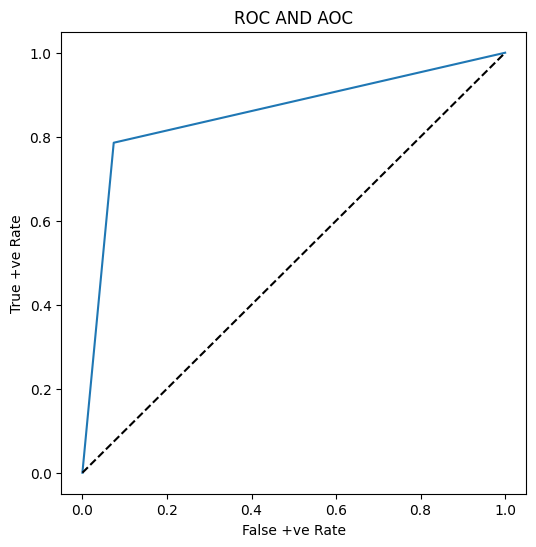

In [76]:
fpr, tpr, thresh= roc_curve(y_smote_test,y_smote_pred_test)
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'k--')
plt.ylabel('True +ve Rate')
plt.xlabel('False +ve Rate')
plt.title("ROC AND AOC")
plt.show()

# Statsmodel for LogisticRegression

In [79]:
import statsmodels.formula.api as sm

In [80]:
default_train=pd.concat([X_train,y_train],axis=1) # all training data
default_test=pd.concat([X_test,y_test],axis=1) # all testing data

In [ ]:
'Total_assets'+'Net_worth'+'Change_in_stock'+'Total_expenses'+'PBDITA'+'PBDITA_as_perc_of_total_income'+'PAT_as_perc_of_total_income'+
'Sales'+'Total_capital'+'Shareholders_funds'+'Cumulative_retained_profits'+'Capital_employed'+'Total_term_liabilities_upon_tangible_net_worth'+
'Net_working_capital'+'Debt_to_equity_ratio_ times'+'Creditors_turnover'+'Finished_goods_turnover'+'Shares_outstanding'+'EPS'+'Adjusted_EPS'+
'Total_liabilities'


In [99]:
logistic_stats1 = sm.logit(formula='default ~ Total_income+Change_in_stock+Total_expenses+PBDITA+PBDITA_as_perc_of_total_income+PAT_as_perc_of_total_income+Sales+Reserves_and_funds+Shareholders_funds+Cumulative_retained_profits+Capital_employed+Net_fixed_assets+Net_working_capital+Creditors_turnover+EPS', data=default_train).fit()

Optimization terminated successfully.
         Current function value: 0.154343
         Iterations 10


In [101]:
logistic_stats1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                 2478
Model:                          Logit   Df Residuals:                     2462
Method:                           MLE   Df Model:                           15
Date:                Sun, 02 Feb 2025   Pseudo R-squ.:                  0.3827
Time:                        02:06:09   Log-Likelihood:                -382.46
converged:                       True   LL-Null:                       -619.53
Covariance Type:            nonrobust   LLR p-value:                 1.657e-91
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          5.3139      0.325     16.338      0.000       4.676       5.951
Total_income                      -3.2131      1.721     -1.867      0.062      -6.587       0.161
Change_in_stock                   -0.5395      0.154     -3.504      0.000      -0.841      -0.238
Total_expenses                    -3.8626      1.008     -3.833      0.000      -5.838      -1.887
PBDITA                             0.5637      0.289      1.950      0.051      -0.003       1.130
PBDITA_as_perc_of_total_income     0.2997      0.143      2.096      0.036       0.019       0.580
PAT_as_perc_of_total_income        0.7590      0.162      4.699      0.000       0.442       1.076
Sales                              7.3311      1.875      3.909      0.000       3.656      11.007
Reserves_and_funds                 0.2882      0.295      0.976      0.329      -0.291       0.867
Shareholders_funds                 0.7439      0.288      2.580      0.010       0.179       1.309
Cumulative_retained_profits        0.7777      0.276      2.820      0.005       0.237       1.318
Capital_employed                  -0.1390      0.271     -0.514      0.607      -0.669       0.391
Net_fixed_assets                  -0.2165      0.231     -0.937      0.349      -0.669       0.236
Net_working_capital                0.5791      0.172      3.371      0.001       0.242       0.916
Creditors_turnover                 0.5207      0.132      3.952      0.000       0.262       0.779
EPS                                1.0650      0.211      5.046      0.000       0.651       1.479
==================================================================================================

Possibly complete quasi-separation: A fraction 0.19 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

### Now based on p_value u can remove some features 0.05